In [45]:
import tensorflow as tf

print(tf.__version__)
print(tf.config.list_physical_devices('GPU'))
print(tf.test.is_built_with_cuda())
# checking complete 

2.21.0
[PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]
True


In [46]:
import tensorflow as tf
from tensorflow.keras import models, layers
import matplotlib.pyplot as plt
import numpy as np


In [47]:
IMAGE_SIZE = 256
BATCH_SIZE = 4
EPOCHS = 50
CHANNELS = 3
n_classes = 3

In [48]:
dataset = tf.keras.preprocessing.image_dataset_from_directory(
    "/mnt/c/development/Thesis/PotatoDiseaseClassification-CNN/DataSets/PlantVillage",
    shuffle=True,
    image_size=(IMAGE_SIZE, IMAGE_SIZE),
    batch_size=BATCH_SIZE
)
class_names = dataset.class_names

Found 2152 files belonging to 3 classes.


In [49]:
print(class_names)

['Potato___Early_blight', 'Potato___Late_blight', 'Potato___healthy']


In [50]:
# Data partition function
def get_dataset_partitions_tf(ds, train_split=0.8, val_split=0.1, test_split=0.1, shuffle=True, shuffle_size=10000):
    ds_size = len(ds)
    if shuffle:
        ds = ds.shuffle(shuffle_size, seed=12)
    train_size = int(train_split * ds_size)
    val_size = int(val_split * ds_size)
    train_ds = ds.take(train_size)
    val_ds = ds.skip(train_size).take(val_size)
    test_ds = ds.skip(train_size).skip(val_size)
    return train_ds, val_ds, test_ds

In [51]:
train_ds, val_ds, test_ds = get_dataset_partitions_tf(dataset)

In [52]:
# Performance Optimization
train_ds = train_ds.shuffle(1000).prefetch(buffer_size=tf.data.AUTOTUNE)
val_ds = val_ds.cache().shuffle(1000).prefetch(buffer_size=tf.data.AUTOTUNE)
test_ds = test_ds.cache().shuffle(1000).prefetch(buffer_size=tf.data.AUTOTUNE)

In [53]:

# 3. Custom Layers for TR-SE-NET

def squeeze_and_excitation_block(input_tensor, ratio=16):
    """SE Block: Channel-based attention mechanism"""
    init = input_tensor
    channel_axis = -1
    filters = init.shape[channel_axis]
    se_shape = (1, 1, filters)

    se = layers.GlobalAveragePooling2D()(init)
    se = layers.Reshape(se_shape)(se)
    se = layers.Dense(filters // ratio, activation='relu', kernel_initializer='he_normal', use_bias=False)(se)
    se = layers.Dense(filters, activation='sigmoid', kernel_initializer='he_normal', use_bias=False)(se)

    return layers.Multiply()([init, se])

In [54]:
def transformer_block(x, num_heads=4, key_dim=64):
    """Transformer Block: Global context understanding"""
    # Multi-head attention
    attention_output = layers.MultiHeadAttention(num_heads=num_heads, key_dim=key_dim)(x, x)
    attention_output = layers.Dropout(0.1)(attention_output)
    x = layers.LayerNormalization(epsilon=1e-6)(x + attention_output)
    
    # Feed Forward Network
    ffn = layers.Dense(x.shape[-1], activation="relu")(x)
    ffn = layers.Dropout(0.1)(ffn)
    x = layers.LayerNormalization(epsilon=1e-6)(x + ffn)
    return x

In [55]:

# 4. Model Creation (TR-SE-NET Architecture)

inputs = layers.Input(shape=(IMAGE_SIZE, IMAGE_SIZE, CHANNELS))

# Pre-processing and Augmentation
x = layers.Resizing(IMAGE_SIZE, IMAGE_SIZE)(inputs)
x = layers.Rescaling(1.0/255)(x)
x = layers.RandomFlip("horizontal_and_vertical")(x)
x = layers.RandomRotation(0.2)(x)

In [56]:

# Stage 1: Initial Feature Extraction (CNN Part)
x = layers.Conv2D(32, (3, 3), activation='relu', padding='same')(x)
x = squeeze_and_excitation_block(x) 
x = layers.MaxPooling2D((2, 2))(x)

# Stage 2: Transformer Block Integration
# Reducing image dimensions so that the transformer can process it efficiently
x = layers.Conv2D(64, (3, 3), activation='relu', padding='same')(x)
x = squeeze_and_excitation_block(x)
x = layers.MaxPooling2D((2, 2))(x)


shape = x.shape
x_reshaped = layers.Reshape((-1, shape[-1]))(x) 
x_transformed = transformer_block(x_reshaped)
x = layers.Reshape((shape[1], shape[2], shape[3]))(x_transformed)

# Stage 3: Final Classification
x = layers.GlobalAveragePooling2D()(x)
x = layers.Dense(64, activation='relu')(x)
outputs = layers.Dense(n_classes, activation='softmax')(x)

In [57]:
model = models.Model(inputs=inputs, outputs=outputs)

In [58]:
model.summary()

Model: "functional_3"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_3       │ (None, 256, 256,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ resizing_3          │ (None, 256, 256,  │          0 │ input_layer_3[0]… │
│ (Resizing)          │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ rescaling_3         │ (None, 256, 256,  │          0 │ resizing_3[0][0]  │
│ (Rescaling)         │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ random_flip_3       │ (None, 256, 256,  │          0 │ rescaling_3[0][0] │
│ (RandomFlip)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ random_rotation_3   │ (None, 256, 256,  │          0 │ random_flip_3[0]… │
│ (RandomRotation)    │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_6 (Conv2D)   │ (None, 256, 256,  │        896 │ random_rotation_… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_average_poo… │ (None, 32)        │          0 │ conv2d_6[0][0]    │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ reshape_12          │ (None, 1, 1, 32)  │          0 │ global_average_p… │
│ (Reshape)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_21 (Dense)    │ (None, 1, 1, 2)   │         64 │ reshape_12[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_22 (Dense)    │ (None, 1, 1, 32)  │         64 │ dense_21[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multiply_6          │ (None, 256, 256,  │          0 │ conv2d_6[0][0],   │
│ (Multiply)          │ 32)               │            │ dense_22[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_6     │ (None, 128, 128,  │          0 │ multiply_6[0][0]  │
│ (MaxPooling2D)      │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_7 (Conv2D)   │ (None, 128, 128,  │     18,496 │ max_pooling2d_6[… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_average_poo… │ (None, 64)        │          0 │ conv2d_7[0][0]    │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ reshape_13          │ (None, 1, 1, 64)  │          0 │ global_average_p… │
│ (Reshape)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_23 (Dense)    │ (None, 1, 1, 4)   │        256 │ reshape_13[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_24 (Dense)    │ (None, 1, 1, 64)  │        256 │ dense_23[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multiply_7          │ (None, 128, 128,  │          0 │ conv2d_7[0][0],   │
│ (Multiply)          │ 64)               │            │ dense_24[0][0]  

 Total params: 95,171 (371.76 KB)

 Trainable params: 95,171 (371.76 KB)

 Non-trainable params: 0 (0.00 B)

In [59]:
# Testing before training get started
for sample_batch, sample_label in train_ds.take(1):
    prediction = model.predict(sample_batch)
    print("Sample prediction successful, shape:", prediction.shape)

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
Sample prediction successful, shape: (4, 3)


In [60]:
# 5. Model compile and Training
model.compile(
    optimizer='adam',
    loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=False),
    metrics=['accuracy']
)

In [61]:
history = model.fit(
    train_ds,
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    verbose=1,
    validation_data=val_ds
)

Epoch 1/50
430/430 ━━━━━━━━━━━━━━━━━━━━ 78s 164ms/step - accuracy: 0.7227 - loss: 0.6820 - val_accuracy: 0.6840 - val_loss: 1.1613
Epoch 2/50
430/430 ━━━━━━━━━━━━━━━━━━━━ 70s 161ms/step - accuracy: 0.8401 - loss: 0.4303 - val_accuracy: 0.8821 - val_loss: 0.3530
Epoch 3/50
430/430 ━━━━━━━━━━━━━━━━━━━━ 70s 161ms/step - accuracy: 0.8674 - loss: 0.3622 - val_accuracy: 0.8774 - val_loss: 0.2816
Epoch 4/50
430/430 ━━━━━━━━━━━━━━━━━━━━ 70s 160ms/step - accuracy: 0.8971 - loss: 0.3045 - val_accuracy: 0.9057 - val_loss: 0.2111
Epoch 5/50
430/430 ━━━━━━━━━━━━━━━━━━━━ 99s 229ms/step - accuracy: 0.9029 - loss: 0.2594 - val_accuracy: 0.7877 - val_loss: 0.4920
Epoch 6/50
430/430 ━━━━━━━━━━━━━━━━━━━━ 70s 161ms/step - accuracy: 0.9081 - loss: 0.2540 - val_accuracy: 0.9481 - val_loss: 0.1463
Epoch 7/50
430/430 ━━━━━━━━━━━━━━━━━━━━ 70s 161ms/step - accuracy: 0.9203 - loss: 0.2082 - val_accuracy: 0.7925 - val_loss: 0.4795
Epoch 8/50
430/430 ━━━━━━━━━━━━━━━━━━━━ 71s 161ms/step - accuracy: 0.9308 - loss: 0

In [62]:
print("Total training batches:", len(train_ds))

Total training batches: 430


In [63]:
# 6. Evaluation and Plotting (Based on your code)
acc = history.history['accuracy']
val_acc = history.history['val_accuracy']
loss = history.history['loss']
val_loss = history.history['val_loss']

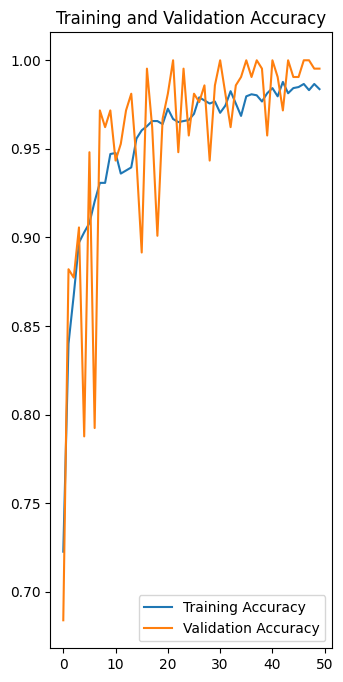

In [64]:
plt.figure(figsize=(8, 8))
plt.subplot(1, 2, 1)
plt.plot(range(EPOCHS), acc, label='Training Accuracy')
plt.plot(range(EPOCHS), val_acc, label='Validation Accuracy')
plt.title('Training and Validation Accuracy')
plt.legend()

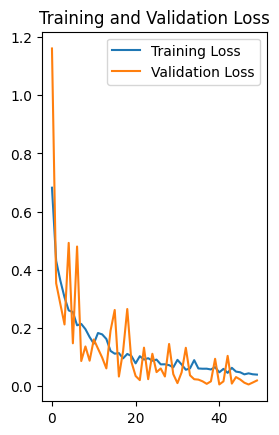

In [65]:
plt.subplot(1, 2, 2)
plt.plot(range(EPOCHS), loss, label='Training Loss')
plt.plot(range(EPOCHS), val_loss, label='Validation Loss')
plt.title('Training and Validation Loss')
plt.legend()
plt.show()

In [69]:
#model.save("./models/plant_tr_se_net_v1.keras")
model.save("/mnt/c/development/Thesis/PotatoDiseaseClassification-CNN/models/plant_tr_se_net_v1.keras")

Loading model... please wait.
Model loaded successfully!
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 559ms/step

 ACTUAL CLASS    : x
 PREDICTED CLASS : Potato___healthy
 CONFIDENCE      : 99.98999786376953%



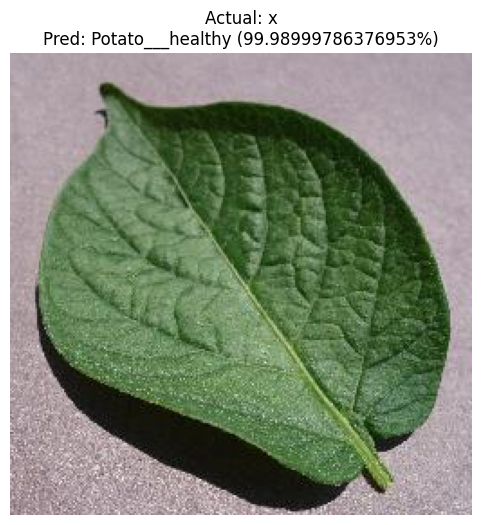

In [73]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt

def test_with_model_path(model_path, image_path, actual_label_name, class_names):
    print("Loading model... please wait.")
    model = tf.keras.models.load_model(model_path)
    print("Model loaded successfully!")
    IMAGE_SIZE = 256 
    img = tf.keras.preprocessing.image.load_img(
        image_path, target_size=(IMAGE_SIZE, IMAGE_SIZE)
    )
    img_array = tf.keras.preprocessing.image.img_to_array(img)
    img_array = tf.expand_dims(img_array, 0) # Batch dimension তৈরি


    predictions = model.predict(img_array)
    predicted_index = np.argmax(predictions[0])
    predicted_class = class_names[predicted_index]
    confidence = round(100 * np.max(predictions[0]), 2)


    print(f"\n" + "="*30)
    print(f" ACTUAL CLASS    : {actual_label_name}")
    print(f" PREDICTED CLASS : {predicted_class}")
    print(f" CONFIDENCE      : {confidence}%")
    print("="*30 + "\n")


    plt.figure(figsize=(6, 6))
    plt.imshow(img)
    plt.title(f"Actual: {actual_label_name}\nPred: {predicted_class} ({confidence}%)")
    plt.axis("off")
    plt.show()


MY_MODEL_PATH = "/mnt/c/development/Thesis/PotatoDiseaseClassification-CNN/models/plant_tr_se_net_v1.keras" 


MY_IMAGE_PATH = "/mnt/c/development/Thesis/PotatoDiseaseClassification-CNN/DataSets/PlantVillage/Potato___healthy/0b3e5032-8ae8-49ac-8157-a1cac3df01dd___RS_HL 1817.JPG"

MY_CLASS_NAMES = ['Potato___Early_blight', 'Potato___Late_blight', 'Potato___healthy']

test_with_model_path(
    model_path=MY_MODEL_PATH,
    image_path=MY_IMAGE_PATH,
    actual_label_name="x",
    class_names=MY_CLASS_NAMES
)